## Sumbit example

In [487]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [488]:
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

print(f"Размер test_data: {test_data.shape}")
train_data

Размер test_data: (5000, 36)


,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,...,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,0.0,66.176500
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,...,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,1.0,28.495737
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,...,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,1.0,34.488104
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,...,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,1.0,36.910753
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,...,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,1.0,31.347091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11012,2010-07-10,57.0,300000.0,850.0,14756.0,48.0,Married,2.0,Own,620.0,...,Employed,Associate,38.0,167544.0,0.094756,0.106387,378.792448,0.039952,1.0,32.440586
11013,2003-10-22,28.0,15000.0,300.0,51361.0,96.0,Single,1.0,Own,696.0,...,Employed,Bachelor,5.0,116879.0,0.446361,0.401087,1793.042130,1.991234,0.0,67.673170
11014,1983-05-12,23.0,15000.0,302.0,30724.0,72.0,Married,3.0,Rent,413.0,...,Self-Employed,Associate,0.0,250778.0,0.404724,0.360670,1047.672294,1.168538,0.0,75.292707
11015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [489]:
train_data = train_data.dropna()
train_data = train_data.drop_duplicates(keep='last')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


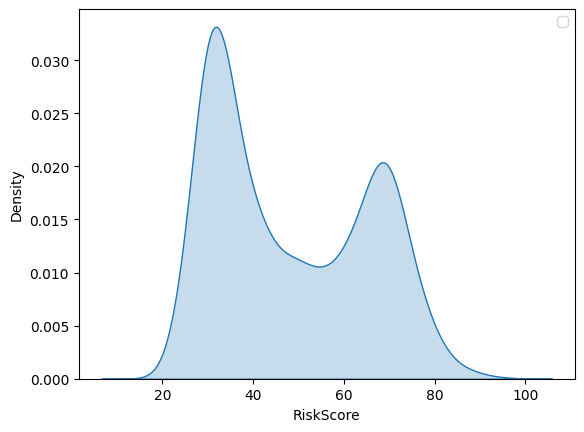

In [490]:
x = train_data.loc[abs(train_data['RiskScore']) < 1000000]
sns.kdeplot(x["RiskScore"], fill=True)
plt.legend()
plt.show()

y = x.pop("RiskScore")

In [491]:
x.pop("ApplicationDate")
x

,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,...,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved
0,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,0.151985,...,4.0,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,0.0
1,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,0.175693,...,2.0,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,1.0
2,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,0.444605,...,3.0,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,1.0
3,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,0.188452,...,3.0,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,1.0
4,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,0.273431,...,5.0,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11010,47.0,88686.0,648.0,5472.0,12.0,Divorced,2.0,Rent,98.0,0.112650,...,4.0,Employed,Bachelor,23.0,121698.0,0.156472,0.164928,497.756143,0.080611,1.0
11011,39.0,300000.0,850.0,7721.0,72.0,Divorced,5.0,Own,276.0,0.215136,...,2.0,Employed,Associate,16.0,18607.0,0.107721,0.108596,146.407421,0.016896,1.0
11012,57.0,300000.0,850.0,14756.0,48.0,Married,2.0,Own,620.0,0.477742,...,4.0,Employed,Associate,38.0,167544.0,0.094756,0.106387,378.792448,0.039952,1.0
11013,28.0,15000.0,300.0,51361.0,96.0,Single,1.0,Own,696.0,0.322554,...,3.0,Employed,Bachelor,5.0,116879.0,0.446361,0.401087,1793.042130,1.991234,0.0


In [492]:
x = pd.get_dummies(x, columns=['MaritalStatus', 'HomeOwnershipStatus', 'EmploymentStatus', 'EducationLevel', 'LoanPurpose'], drop_first=True)
x

,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,...,EmploymentStatus_Self-Employed,EmploymentStatus_Unemployed,EducationLevel_Bachelor,EducationLevel_Doctorate,EducationLevel_High School,EducationLevel_Master,LoanPurpose_Debt Consolidation,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,27.0,66829.0,549.0,17290.0,60.0,1.0,1095.0,0.151985,2.0,1.0,...,False,False,False,False,False,False,False,True,False,False
1,55.0,172147.0,850.0,16110.0,36.0,1.0,211.0,0.175693,3.0,0.0,...,False,False,False,False,True,False,False,False,True,False
2,51.0,300000.0,850.0,38436.0,36.0,0.0,546.0,0.444605,3.0,0.0,...,False,False,True,False,False,False,False,True,False,False
3,25.0,34683.0,847.0,19186.0,48.0,0.0,153.0,0.188452,7.0,0.0,...,False,False,False,False,True,False,True,False,False,False
4,55.0,300000.0,850.0,30437.0,48.0,2.0,562.0,0.273431,3.0,1.0,...,False,False,True,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11010,47.0,88686.0,648.0,5472.0,12.0,2.0,98.0,0.112650,8.0,1.0,...,False,False,True,False,False,False,False,False,True,False
11011,39.0,300000.0,850.0,7721.0,72.0,5.0,276.0,0.215136,2.0,1.0,...,False,False,False,False,False,False,False,False,True,False
11012,57.0,300000.0,850.0,14756.0,48.0,2.0,620.0,0.477742,1.0,3.0,...,False,False,False,False,False,False,False,True,False,False
11013,28.0,15000.0,300.0,51361.0,96.0,1.0,696.0,0.322554,2.0,0.0,...,False,False,True,False,False,False,False,False,True,False


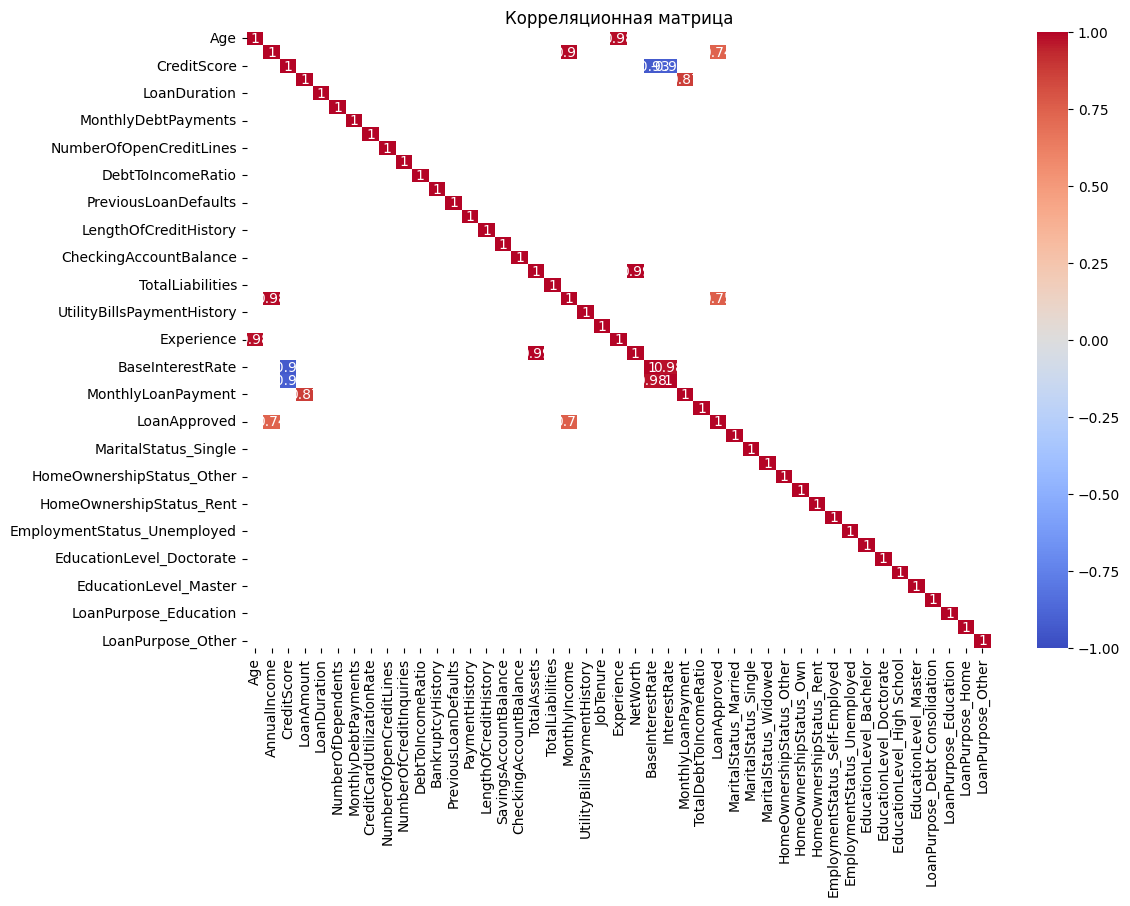

In [493]:
corr_matrix = x.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix[corr_matrix.abs() >= 0.7], annot=True,  cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Корреляционная матрица")
plt.show()

In [494]:
model = LinearRegression()
model.fit(x, y)

LinearRegression()

In [495]:
reg = LinearRegression().fit(x, y)
train_predictions = reg.predict(x)

In [496]:
mse = mean_squared_error(y, train_predictions)
print(f'Mean Squared Error on validation set: {mse}')

Mean Squared Error on validation set: 19.009391963872257


In [497]:
test_data.pop("ApplicationDate")
test_data = pd.get_dummies(test_data, columns=['MaritalStatus', 'HomeOwnershipStatus', 'EmploymentStatus', 'EducationLevel', 'LoanPurpose'], drop_first=True)

In [498]:
test_data = test_data.drop(["ID", "NetWorth", "Experience", "BaseInterestRate"], axis=1)

In [499]:
train_features = set(x.columns)
test_features = set(test_data.columns)
missing_features = train_features - test_features
extra_features = test_features - train_features

print("Отсутствующие признаки:", missing_features)
print("Лишние признаки:", extra_features)

Отсутствующие признаки: {'BaseInterestRate', 'Experience', 'NetWorth'}
Лишние признаки: set()


In [500]:
for feature in missing_features:
    test_data[feature] = 0 

In [501]:
test_data = test_data.drop(columns=extra_features)

In [502]:
test_data = test_data[test_data.columns]
test_data

,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,...,EducationLevel_Doctorate,EducationLevel_High School,EducationLevel_Master,LoanPurpose_Debt Consolidation,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,BaseInterestRate,Experience,NetWorth
0,49,207095,850,14458,60,0,376,0.077124,2,0,...,False,True,False,False,False,False,False,0,0,0
1,28,64653,674,65491,48,2,238,0.073977,4,2,...,False,True,False,False,True,False,False,0,0,0
2,41,300000,768,16811,60,1,469,0.331499,5,0,...,False,True,False,False,False,False,False,0,0,0
3,50,300000,850,48737,36,0,567,0.544696,2,1,...,False,False,False,False,True,False,False,0,0,0
4,35,300000,672,51916,60,6,106,0.436103,0,0,...,False,False,False,False,False,True,False,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,40,300000,850,12696,60,1,434,0.062521,5,1,...,False,False,True,False,False,True,False,0,0,0
4996,39,75014,572,49380,48,0,97,0.057142,2,1,...,False,False,True,False,True,False,False,0,0,0
4997,43,15000,454,32810,72,1,289,0.403643,2,0,...,False,False,False,False,False,False,True,0,0,0
4998,53,98467,850,28446,96,1,213,0.137445,1,1,...,False,True,False,False,False,False,True,0,0,0


In [503]:
print("Форма x_train:", x.shape)
print("Форма x_test:", test_data.shape)
assert x.shape[1] == test_data.shape[1], "Количество признаков все еще не совпадает"

Форма x_train: (9332, 45)
Форма x_test: (5000, 45)


In [504]:
test_data = test_data.reindex(columns=reg.feature_names_in_, fill_value=0)
assert all(test_data.columns == reg.feature_names_in_), "Признаки все еще не совпадают"

In [505]:
test_predictions = pd.DataFrame(reg.predict(test_data), columns=["RiskScore"])
test_predictions.to_csv("submission.csv")